# BLS (Batch Least Squares) — Modelo 1/4 Drone
**Dataset:** `step_39_open.csv` — resposta ao degrau em malha aberta (Aeropêndulo)

**Metodologia:**
- Identificação (treinamento) nos primeiros **70%** dos dados
- Validação nos **30%** restantes (dados não vistos durante a estimação)

In [171]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.fft
from sklearn.metrics import mean_squared_error, r2_score

## 1. Ingestão e Pré-processamento dos Dados

In [172]:
# -----------------------------------------------------------------------
# Função auxiliar de carregamento
# -----------------------------------------------------------------------
def carregar_experimento(url, decimacao=1, start_idx=0, end_idx=None):
    df = pd.read_csv(url)
    df_sub = df.iloc[::decimacao].copy().reset_index(drop=True)
    
    # Suporte para cabeçalhos antigos (motor_percent) e novos (u_pct)
    if 'u_pct' in df_sub.columns:
        u_raw = df_sub['u_pct'].values
    else:
        u_raw = df_sub['motor_percent'].values
        
    y_raw = df_sub['angulo_deg'].values
    
    if end_idx is None:
        end_idx = len(u_raw)
        
    u = u_raw[start_idx:end_idx]
    y = y_raw[start_idx:end_idx]
    return u, y
    
BASE = (
    "https://raw.githubusercontent.com/FelipeEduardoMarcondes/"
    "SYSTEM-IDENTIFICATION-AERO/main/PYTHON/dados/"
)

BASE2 = (
    "https://raw.githubusercontent.com/FelipeEduardoMarcondes/"
    "SYSTEM-IDENTIFICATION-AERO/main/experimentos/"
)


# Define limites de corte para remover ruído inicial e final
CUT_TRA_START = 1500
CUT_TRA_END = -1400

CUT_TEST_START = 1500
CUT_TEST_END = -1400

u_TRA,  y_TRA  = carregar_experimento(BASE2 + "RODADA-1/multi-sine-1_0731_17-34.csv", start_idx=CUT_TRA_START, end_idx=CUT_TRA_END) # Estimação
u_TEST, y_TEST = carregar_experimento(BASE2 + "RODADA-1/multi-sine-3_0731_17-45.csv", start_idx=CUT_TEST_START, end_idx=CUT_TEST_END) # Teste  # Teste 

N_total = len(u_TRA)
print(f"TRA : {len(u_TRA)} amostras")
print(f"TEST: {len(u_TEST)} amostras")

TRA : 6904 amostras
TEST: 6714 amostras


## 2. Separação Treinamento / Validação (70% / 30%)

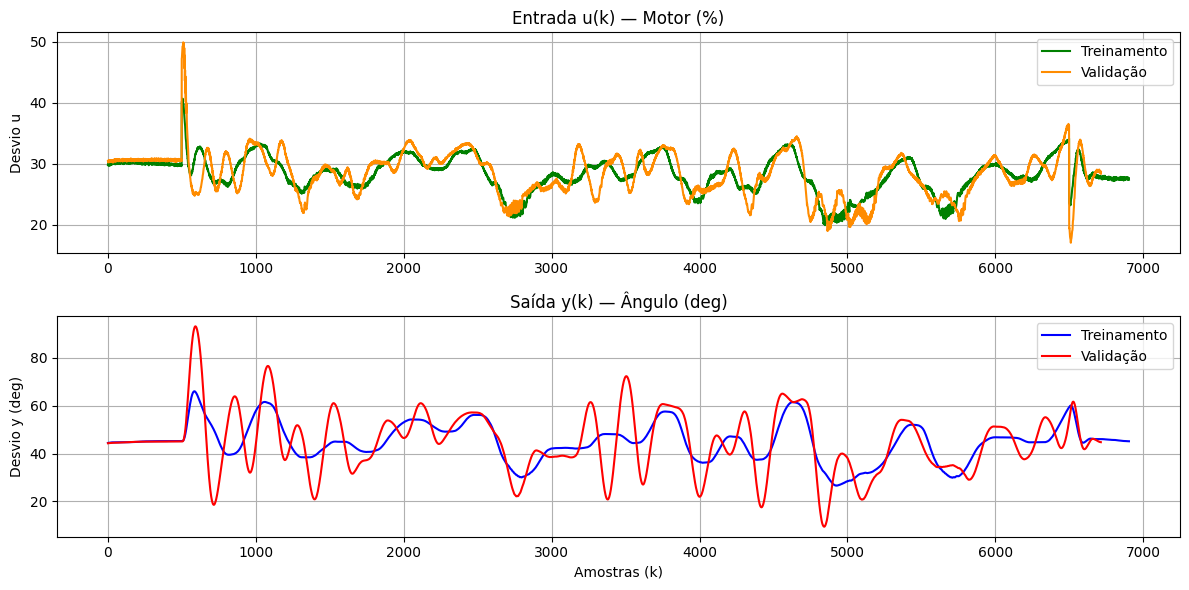

In [173]:


# Visualização
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(u_TRA,  color='green',      lw=1.5, label='Treinamento')
axes[0].plot(u_TEST, color='darkorange', lw=1.5, label='Validação')
axes[0].set_title('Entrada u(k) — Motor (%)')
axes[0].set_ylabel('Desvio u')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(y_TRA,  color='blue', lw=1.5, label='Treinamento')
axes[1].plot(y_TEST, color='red',  lw=1.5, label='Validação')
axes[1].set_title('Saída y(k) — Ângulo (deg)')
axes[1].set_ylabel('Desvio y (deg)')
axes[1].set_xlabel('Amostras (k)')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

## 3. Funções Auxiliares: Matriz de Regressão e Simulação Free-Run

In [174]:
def create_regression_matrix(u, y, na, nb):
    """
    Constrói a matriz de regressão Phi e o vetor alvo y_target
    para um modelo ARX de ordens na (saída) e nb (entrada).

    Linha de Phi em k: [-y(k-1), ..., -y(k-na), u(k-1), ..., u(k-nb)]
    """
    u = np.asarray(u).flatten()
    y = np.asarray(y).flatten()
    N = len(y)
    if N != len(u):
        raise ValueError("Dimensões de u e y inconsistentes!")

    p = max(na, nb)
    y_target = y[p:]
    Phi = np.zeros((N - p, na + nb))

    for i in range(1, na + 1):
        Phi[:, i - 1] = -y[p - i: N - i]
    for i in range(1, nb + 1):
        Phi[:, na + i - 1] = u[p - i: N - i]

    return Phi, y_target


def free_run_simulation(th_hat, u, y_measured, na, nb):
    """
    Simulação Free-Run: usa apenas saídas simuladas anteriores
    (sem realimentação das saídas medidas após as condições iniciais).
    """
    u = np.asarray(u).flatten()
    y_measured = np.asarray(y_measured).flatten()
    N = len(u)
    p = max(na, nb)
    y_sim = np.zeros(N)
    y_sim[:p] = y_measured[:p]   # condições iniciais = dados medidos

    for k in range(p, N):
        # Utilizando a função do passo 1 (create_regression_matrix) para construir o regressor.
        # Passamos uma janela de p+1 amostras (do instante k-p até k)
        u_window = u[k-p : k+1]
        y_window = y_sim[k-p : k+1]
        
        # A função retorna a matriz de regressão (Phi) com 1 linha e o vetor y_target.
        Phi_k_matrix, _ = create_regression_matrix(u_window, y_window, na, nb)
        
        # Faz a predição para o instante k
        y_sim[k] = Phi_k_matrix[0] @ th_hat

    return y_sim[p:]


def calcular_metricas(y_real, y_pred, label=""):
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2   = r2_score(y_real, y_pred)
    print(f"  {label:30s} → RMSE: {rmse:.6e}  |  R²: {r2:.6f}")
    return rmse, r2


def espectro_amplitude(sinal, Ts):
    N   = len(sinal)
    xf  = scipy.fft.fftfreq(N, Ts)[:N // 2]
    amp = 2.0 / N * np.abs(scipy.fft.fft(sinal)[:N // 2])
    return xf, amp

## 4. Identificação BLS — Apenas Dados de Treinamento

In [175]:
na = 30
nb = 30

# Matrizes de regressão: TREINAMENTO e VALIDAÇÃO
Phi_TRA,  y_target_TRA  = create_regression_matrix(u_TRA,  y_TRA,  na, nb)
Phi_TEST, y_target_TEST = create_regression_matrix(u_TEST, y_TEST, na, nb)

# Estimação dos parâmetros SOMENTE com dados de treinamento
th_hat, _, _, _ = np.linalg.lstsq(Phi_TRA, y_target_TRA, rcond=None)

print("Parâmetros estimados pelo BLS (treinamento):")
print(f"  a1 = {th_hat[0]:.6f}")
print(f"  a2 = {th_hat[1]:.6f}")
print(f"  b1 = {th_hat[2]:.6f}")
print(f"  b2 = {th_hat[3]:.6f}")

# Formatação correta da equação (evita "+ -")
a_c = -th_hat[:na]
b_c =  th_hat[na:]
ty = [f"{'+' if (i>0 and a_c[i]>=0) else ('-' if i>0 else '')} {abs(a_c[i]):.4f}·y(k-{i+1})" for i in range(na)]
tu = [f"{'+' if b_c[i]>=0 else '-'} {abs(b_c[i]):.4f}·u(k-{i+1})" for i in range(nb)]
print(f"\nModelo ARX (na={na}, nb={nb}):")
print("  y(k) = " + " ".join(ty) + "  " + "  ".join(tu))

Parâmetros estimados pelo BLS (treinamento):
  a1 = -1.339578
  a2 = 0.065417
  b1 = 0.190061
  b2 = 0.048769

Modelo ARX (na=30, nb=30):
  y(k) =  1.3396·y(k-1) - 0.0654·y(k-2) - 0.1901·y(k-3) - 0.0488·y(k-4) - 0.0028·y(k-5) + 0.0072·y(k-6) + 0.0014·y(k-7) + 0.0509·y(k-8) - 0.1017·y(k-9) + 0.0347·y(k-10) + 0.0311·y(k-11) + 0.0311·y(k-12) - 0.0187·y(k-13) - 0.0673·y(k-14) + 0.0461·y(k-15) - 0.0418·y(k-16) - 0.0397·y(k-17) + 0.0154·y(k-18) - 0.0002·y(k-19) - 0.0210·y(k-20) + 0.0158·y(k-21) + 0.0499·y(k-22) - 0.0203·y(k-23) + 0.0171·y(k-24) - 0.0398·y(k-25) - 0.0273·y(k-26) + 0.0108·y(k-27) + 0.0317·y(k-28) - 0.0719·y(k-29) + 0.0738·y(k-30)  - 0.0077·u(k-1)  + 0.0071·u(k-2)  + 0.0008·u(k-3)  + 0.0007·u(k-4)  - 0.0004·u(k-5)  + 0.0005·u(k-6)  + 0.0007·u(k-7)  + 0.0001·u(k-8)  + 0.0003·u(k-9)  + 0.0003·u(k-10)  + 0.0010·u(k-11)  - 0.0008·u(k-12)  + 0.0010·u(k-13)  + 0.0004·u(k-14)  + 0.0005·u(k-15)  - 0.0004·u(k-16)  + 0.0002·u(k-17)  + 0.0005·u(k-18)  - 0.0003·u(k-19)  - 0.0003·u(k-20)  -

## 5. Predição OSA — Treinamento e Validação

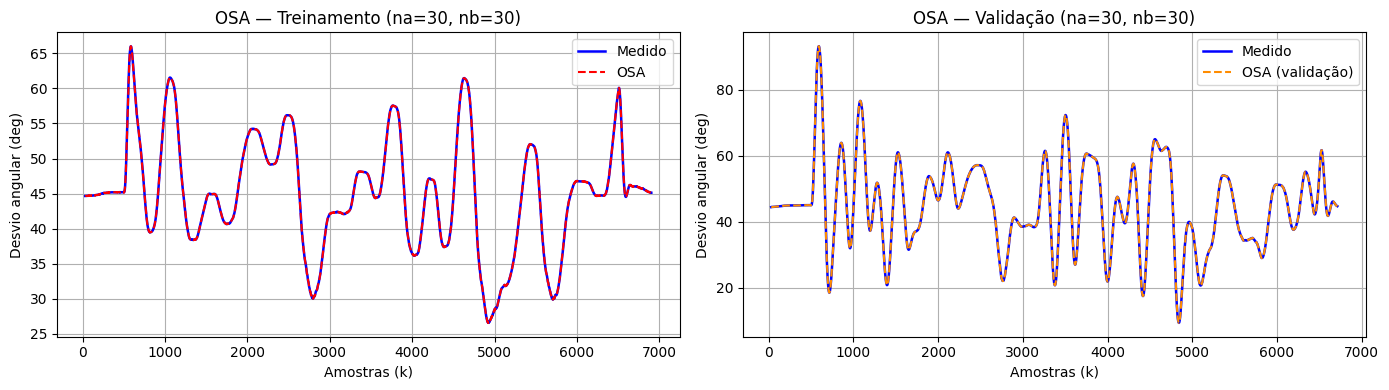

In [176]:
p = max(na, nb)

yhat_OSA_TRA  = Phi_TRA  @ th_hat
yhat_OSA_TEST = Phi_TEST @ th_hat

t_TRA  = np.arange(p, len(y_TRA))   # ← era np.arange(p, split)
t_TEST = np.arange(p, len(y_TEST))  # ← era np.arange(split + p, N_total)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(t_TRA, y_target_TRA,  color='blue',      lw=1.8, label='Medido')
axes[0].plot(t_TRA, yhat_OSA_TRA,  color='red',       lw=1.5, ls='--', label='OSA')
axes[0].set_title(f'OSA — Treinamento (na={na}, nb={nb})')
axes[0].set_xlabel('Amostras (k)'); axes[0].set_ylabel('Desvio angular (deg)')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(t_TEST, y_target_TEST,  color='blue',       lw=1.8, label='Medido')
axes[1].plot(t_TEST, yhat_OSA_TEST,  color='darkorange',  lw=1.5, ls='--', label='OSA (validação)')
axes[1].set_title(f'OSA — Validação (na={na}, nb={nb})')
axes[1].set_xlabel('Amostras (k)'); axes[1].set_ylabel('Desvio angular (deg)')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

## 6. Simulação Free-Run — Treinamento e Validação

Executando Free-Run (treinamento)...
Executando Free-Run (validação)...
Concluído.


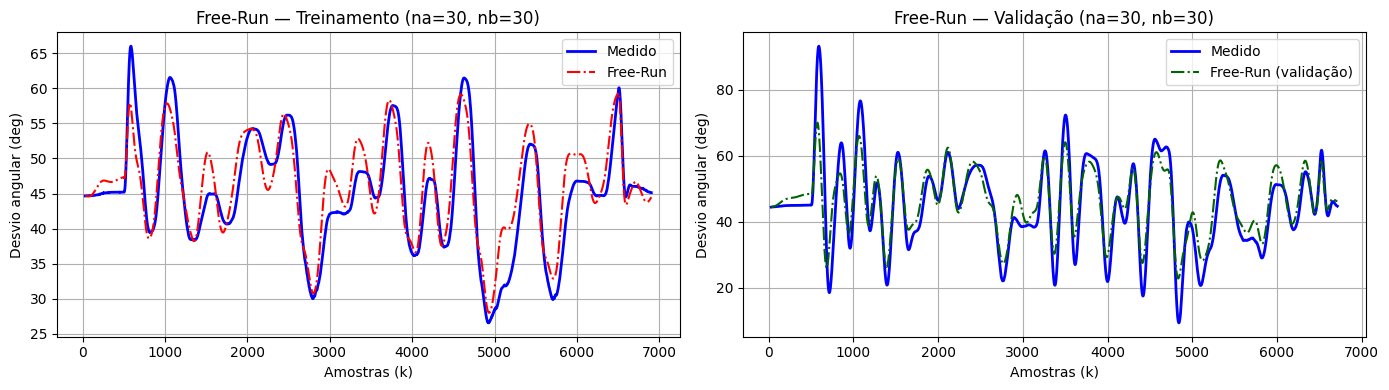

In [177]:
print("Executando Free-Run (treinamento)...")
yhat_FR_TRA  = free_run_simulation(th_hat, u_TRA,  y_TRA,  na, nb)
print("Executando Free-Run (validação)...")
yhat_FR_TEST = free_run_simulation(th_hat, u_TEST, y_TEST, na, nb)
print("Concluído.")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(t_TRA, y_target_TRA,  color='blue',  lw=2.0, label='Medido')
axes[0].plot(t_TRA, yhat_FR_TRA,   color='red',   lw=1.5, ls='-.', label='Free-Run')
axes[0].set_title(f'Free-Run — Treinamento (na={na}, nb={nb})')
axes[0].set_xlabel('Amostras (k)'); axes[0].set_ylabel('Desvio angular (deg)')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(t_TEST, y_target_TEST,  color='blue',      lw=2.0, label='Medido')
axes[1].plot(t_TEST, yhat_FR_TEST,   color='darkgreen', lw=1.5, ls='-.', label='Free-Run (validação)')
axes[1].set_title(f'Free-Run — Validação (na={na}, nb={nb})')
axes[1].set_xlabel('Amostras (k)'); axes[1].set_ylabel('Desvio angular (deg)')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

## 7. Métricas de Desempenho — Treinamento vs Validação

In [178]:
print("=" * 60)
print(f"MODELO: na={na}, nb={nb}")
print("=" * 60)
print("\n[TREINAMENTO]")
calcular_metricas(y_target_TRA,  yhat_OSA_TRA,  "OSA")
calcular_metricas(y_target_TRA,  yhat_FR_TRA,   "Free-Run")
print("\n[VALIDAÇÃO]")
calcular_metricas(y_target_TEST, yhat_OSA_TEST, "OSA")
calcular_metricas(y_target_TEST, yhat_FR_TEST,  "Free-Run")
print("=" * 60)

MODELO: na=30, nb=30

[TREINAMENTO]
  OSA                            → RMSE: 1.051272e-02  |  R²: 0.999998
  Free-Run                       → RMSE: 3.662670e+00  |  R²: 0.784072

[VALIDAÇÃO]
  OSA                            → RMSE: 1.280003e-02  |  R²: 0.999999
  Free-Run                       → RMSE: 5.841449e+00  |  R²: 0.793392


## 8. Análise de Resíduos — Espectro (FFT)

Comparação do espectro do sinal medido, predições (OSA e FR) e erros — tanto no treinamento quanto na validação.

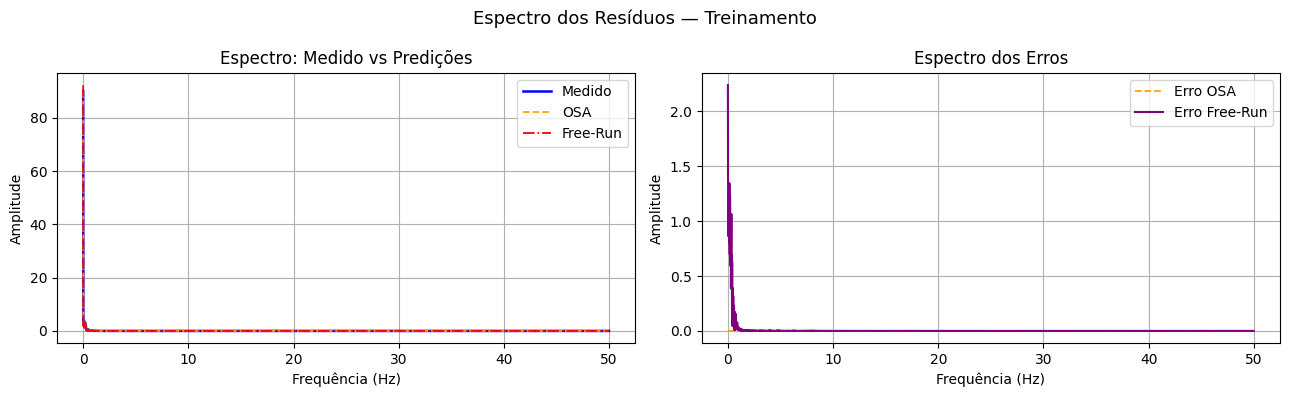

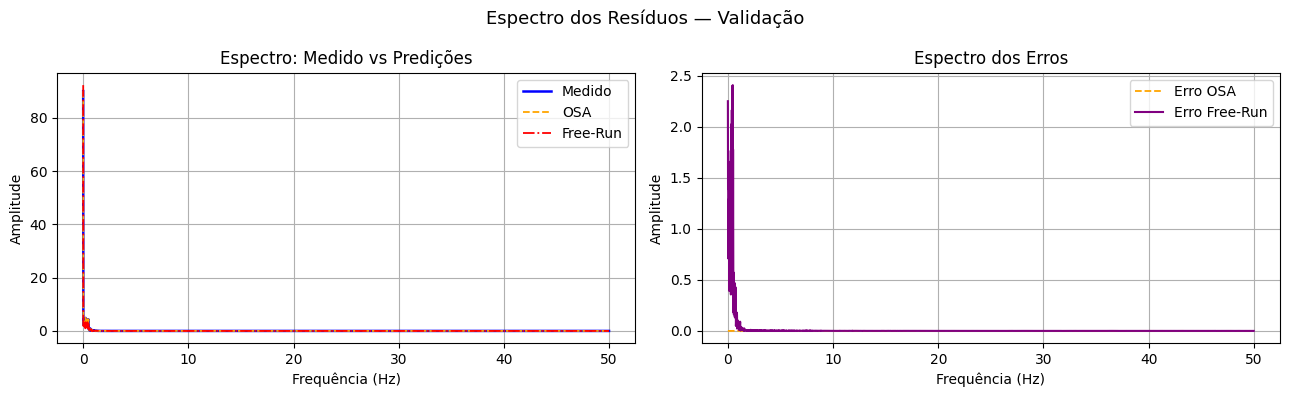

In [179]:
Ts = 0.01   # Ts_original(0.01 s) × fator de decimação(30)

for (y_real, yhat_osa, yhat_fr, titulo) in [
    (y_target_TRA,  yhat_OSA_TRA,  yhat_FR_TRA,  "Treinamento"),
    (y_target_TEST, yhat_OSA_TEST, yhat_FR_TEST, "Validação"),
]:
    erro_OSA = y_real.flatten() - yhat_osa.flatten()
    erro_FR  = y_real.flatten() - yhat_fr.flatten()

    xf, amp_med  = espectro_amplitude(y_real.flatten(),  Ts)
    _,  amp_osa  = espectro_amplitude(yhat_osa.flatten(), Ts)
    _,  amp_fr   = espectro_amplitude(yhat_fr.flatten(),  Ts)
    _,  amp_eOSA = espectro_amplitude(erro_OSA, Ts)
    _,  amp_eFR  = espectro_amplitude(erro_FR,  Ts)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'Espectro dos Resíduos — {titulo}', fontsize=13)

    axes[0].plot(xf, amp_med,  label='Medido',  color='blue',   lw=1.8)
    axes[0].plot(xf, amp_osa,  label='OSA',      color='orange', lw=1.3, ls='--')
    axes[0].plot(xf, amp_fr,   label='Free-Run', color='red',    lw=1.3, ls='-.')
    axes[0].set_title('Espectro: Medido vs Predições')
    axes[0].set_xlabel('Frequência (Hz)'); axes[0].set_ylabel('Amplitude')
    axes[0].legend(); axes[0].grid(True)

    axes[1].plot(xf, amp_eOSA, label='Erro OSA',      color='orange', lw=1.3, ls='--')
    axes[1].plot(xf, amp_eFR,  label='Erro Free-Run', color='purple', lw=1.5)
    axes[1].set_title('Espectro dos Erros')
    axes[1].set_xlabel('Frequência (Hz)'); axes[1].set_ylabel('Amplitude')
    axes[1].legend(); axes[1].grid(True)

    plt.tight_layout()
    plt.show()

## 9. Comparação de Ordens do Modelo

Treinamento em TRA, avaliação em TEST (generalização real do modelo).

In [184]:
ordens_teste = [(1,1),(1,2),(2,1),(2,2),(3,2),(2,3),(3,3),(4,3),(4,4),(8, 24), (24, 8), (25, 25), (30, 30), (30, 50), (50, 30), (50, 50), (60, 60)] 
resultados = []

for na_t, nb_t in ordens_teste:
    Phi_tra, y_tra = create_regression_matrix(u_TRA,  y_TRA,  na_t, nb_t)
    Phi_tst, y_tst = create_regression_matrix(u_TEST, y_TEST, na_t, nb_t)

    th_t, _, _, _ = np.linalg.lstsq(Phi_tra, y_tra, rcond=None)

    # Treinamento
    osa_tra = Phi_tra @ th_t
    fr_tra  = free_run_simulation(th_t, u_TRA,  y_TRA,  na_t, nb_t)
    # Validação
    osa_tst = Phi_tst @ th_t
    fr_tst  = free_run_simulation(th_t, u_TEST, y_TEST, na_t, nb_t)

    resultados.append({
        'na': na_t, 'nb': nb_t,
        'RMSE_OSA_TRA': np.sqrt(mean_squared_error(y_tra, osa_tra)),
        'R2_OSA_TRA':   r2_score(y_tra, osa_tra),
        'RMSE_FR_TRA':  np.sqrt(mean_squared_error(y_tra, fr_tra)),
        'R2_FR_TRA':    r2_score(y_tra, fr_tra),
        'RMSE_OSA_TST': np.sqrt(mean_squared_error(y_tst, osa_tst)),
        'R2_OSA_TST':   r2_score(y_tst, osa_tst),
        'RMSE_FR_TST':  np.sqrt(mean_squared_error(y_tst, fr_tst)),
        'R2_FR_TST':    r2_score(y_tst, fr_tst),
    })

df_res = pd.DataFrame(resultados)
print(df_res.to_string(index=False, float_format="{:.4f}".format))

# Melhor modelo pelo R² Free-Run na VALIDAÇÃO
best = df_res.loc[df_res['R2_FR_TST'].idxmax()]
print(f"\nMelhor configuração (R² Free-Run na Validação): na={int(best.na)}, nb={int(best.nb)}")
print(f"  TRA → RMSE_FR={best.RMSE_FR_TRA:.4f}  R²_FR={best.R2_FR_TRA:.4f}")
print(f"  TST → RMSE_FR={best.RMSE_FR_TST:.4f}  R²_FR={best.R2_FR_TST:.4f}")

 na  nb  RMSE_OSA_TRA  R2_OSA_TRA  RMSE_FR_TRA  R2_FR_TRA  RMSE_OSA_TST  R2_OSA_TST  RMSE_FR_TST  R2_FR_TST
  1   1        0.0812      0.9999       5.8315     0.4503        0.2546      0.9996      11.3331     0.2189
  1   2        0.0812      0.9999       5.8257     0.4515        0.2542      0.9996      11.3217     0.2206
  2   1        0.0123      1.0000       3.4996     0.8021        0.0146      1.0000       8.9422     0.5138
  2   2        0.0122      1.0000       3.4698     0.8054        0.0145      1.0000       8.9742     0.5103
  3   2        0.0114      1.0000       3.1774     0.8369        0.0140      1.0000       8.7117     0.5386
  2   3        0.0122      1.0000       3.4669     0.8058        0.0145      1.0000       8.9898     0.5087
  3   3        0.0113      1.0000       3.1637     0.8383        0.0140      1.0000       8.7291     0.5368
  4   3        0.0112      1.0000       3.1319     0.8415        0.0142      1.0000       8.8173     0.5274
  4   4        0.0112      1

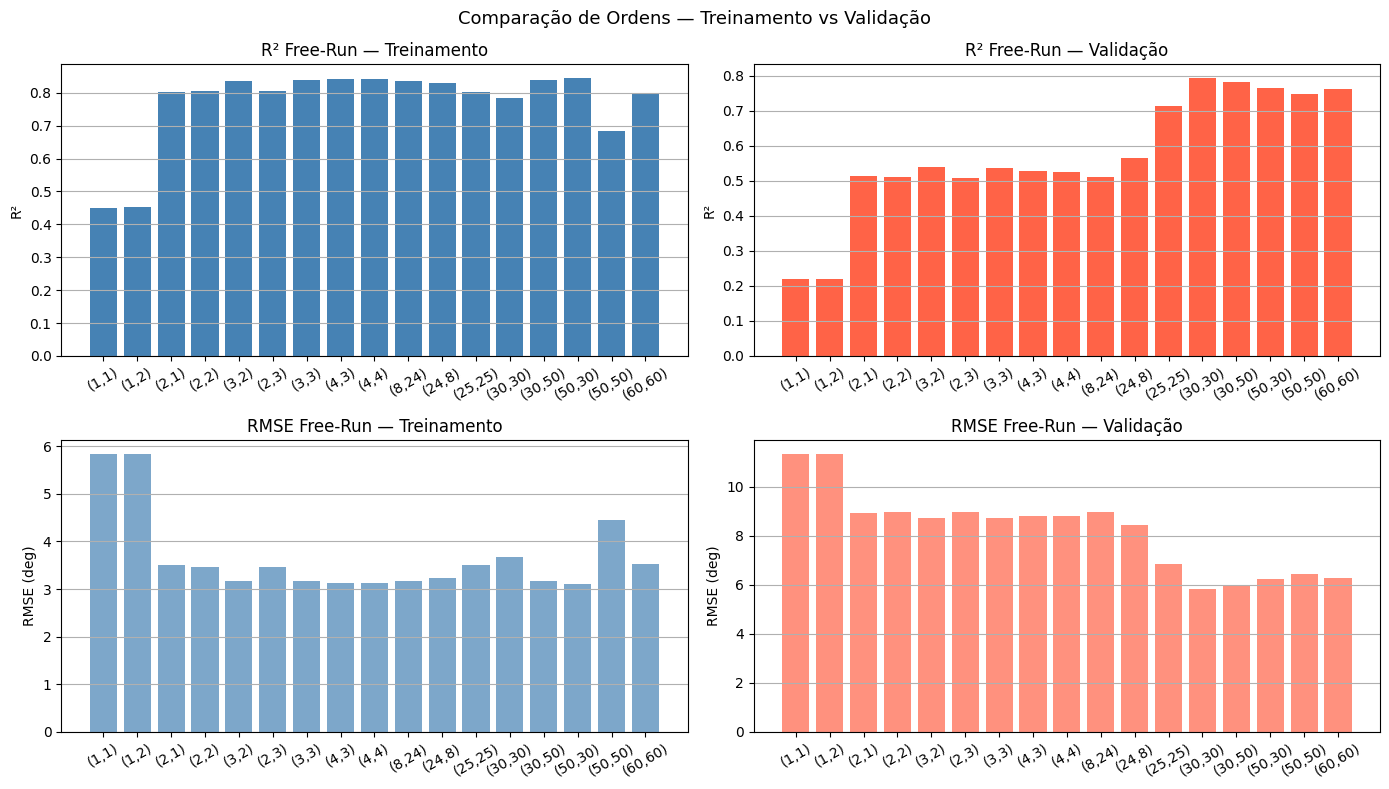

In [185]:
labels = [f"({r.na},{r.nb})" for r in df_res.itertuples()]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Comparação de Ordens — Treinamento vs Validação', fontsize=13)

axes[0,0].bar(labels, df_res['R2_FR_TRA'],  color='steelblue')
axes[0,0].set_title('R² Free-Run — Treinamento')
axes[0,0].set_ylabel('R²'); axes[0,0].tick_params(axis='x', rotation=30); axes[0,0].grid(axis='y')

axes[0,1].bar(labels, df_res['R2_FR_TST'],  color='tomato')
axes[0,1].set_title('R² Free-Run — Validação')
axes[0,1].set_ylabel('R²'); axes[0,1].tick_params(axis='x', rotation=30); axes[0,1].grid(axis='y')

axes[1,0].bar(labels, df_res['RMSE_FR_TRA'], color='steelblue', alpha=0.7)
axes[1,0].set_title('RMSE Free-Run — Treinamento')
axes[1,0].set_ylabel('RMSE (deg)'); axes[1,0].tick_params(axis='x', rotation=30); axes[1,0].grid(axis='y')

axes[1,1].bar(labels, df_res['RMSE_FR_TST'], color='tomato', alpha=0.7)
axes[1,1].set_title('RMSE Free-Run — Validação')
axes[1,1].set_ylabel('RMSE (deg)'); axes[1,1].tick_params(axis='x', rotation=30); axes[1,1].grid(axis='y')

plt.tight_layout()
plt.show()

## 10. Plot output: Real vs Estimado — Melhor Modelo

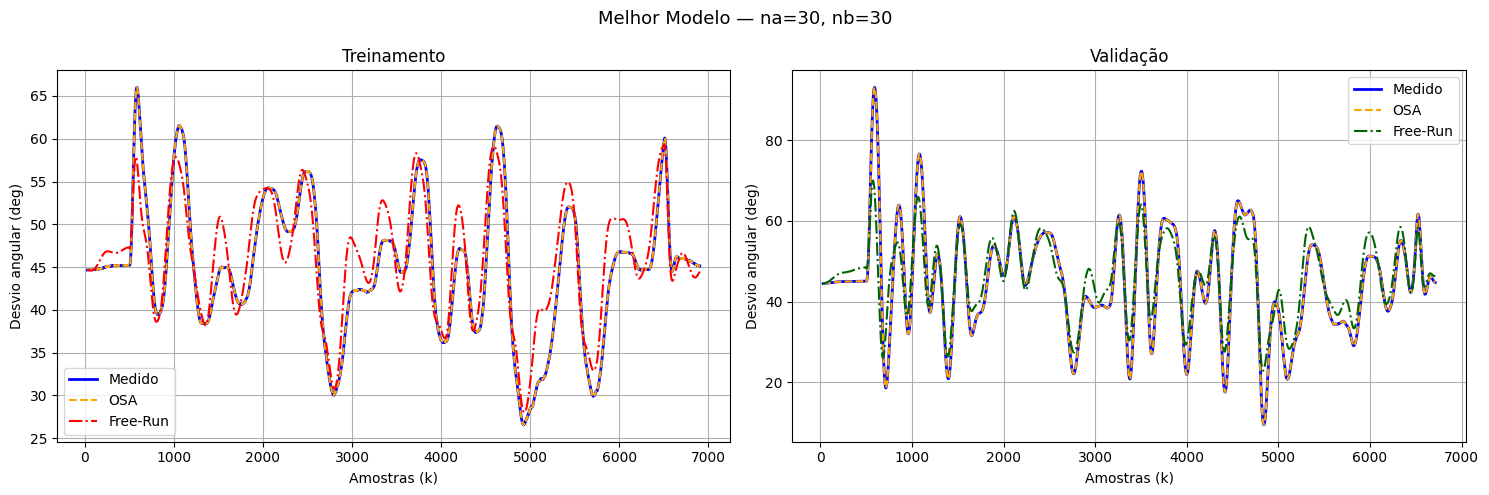


Métricas finais — na=30, nb=30
[Treinamento]
  OSA                            → RMSE: 1.051272e-02  |  R²: 0.999998
  Free-Run                       → RMSE: 3.662670e+00  |  R²: 0.784072
[Validação]
  OSA                            → RMSE: 1.280003e-02  |  R²: 0.999999
  Free-Run                       → RMSE: 5.841449e+00  |  R²: 0.793392


(np.float64(5.8414493928636855), 0.7933917187411839)

In [182]:
na_b, nb_b = int(best.na), int(best.nb)
p_b = max(na_b, nb_b)

Phi_tra_b, y_tra_b = create_regression_matrix(u_TRA,  y_TRA,  na_b, nb_b)
Phi_tst_b, y_tst_b = create_regression_matrix(u_TEST, y_TEST, na_b, nb_b)
th_b, _, _, _ = np.linalg.lstsq(Phi_tra_b, y_tra_b, rcond=None)

osa_tra_b = Phi_tra_b @ th_b
fr_tra_b  = free_run_simulation(th_b, u_TRA,  y_TRA,  na_b, nb_b)
osa_tst_b = Phi_tst_b @ th_b
fr_tst_b  = free_run_simulation(th_b, u_TEST, y_TEST, na_b, nb_b)

t_tra_b = np.arange(p_b, len(y_TRA))
t_tst_b = np.arange(p_b, len(y_TEST))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(f'Melhor Modelo — na={na_b}, nb={nb_b}', fontsize=13)

axes[0].plot(t_tra_b, y_tra_b,  color='blue',   lw=2.0, label='Medido')
axes[0].plot(t_tra_b, osa_tra_b, color='orange', lw=1.5, ls='--', label='OSA')
axes[0].plot(t_tra_b, fr_tra_b,  color='red',    lw=1.5, ls='-.', label='Free-Run')
axes[0].set_title('Treinamento')
axes[0].set_xlabel('Amostras (k)'); axes[0].set_ylabel('Desvio angular (deg)')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(t_tst_b, y_tst_b,  color='blue',      lw=2.0, label='Medido')
axes[1].plot(t_tst_b, osa_tst_b, color='orange',    lw=1.5, ls='--', label='OSA')
axes[1].plot(t_tst_b, fr_tst_b,  color='darkgreen', lw=1.5, ls='-.', label='Free-Run')
axes[1].set_title('Validação')
axes[1].set_xlabel('Amostras (k)'); axes[1].set_ylabel('Desvio angular (deg)')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"\nMétricas finais — na={na_b}, nb={nb_b}")
print("[Treinamento]")
calcular_metricas(y_tra_b, osa_tra_b, "OSA")
calcular_metricas(y_tra_b, fr_tra_b,  "Free-Run")
print("[Validação]")
calcular_metricas(y_tst_b, osa_tst_b, "OSA")
calcular_metricas(y_tst_b, fr_tst_b,  "Free-Run")

Pior configuração (R² Free-Run na Validação): na=1, nb=1
Melhor configuração (R² Free-Run na Validação): na=30, nb=30


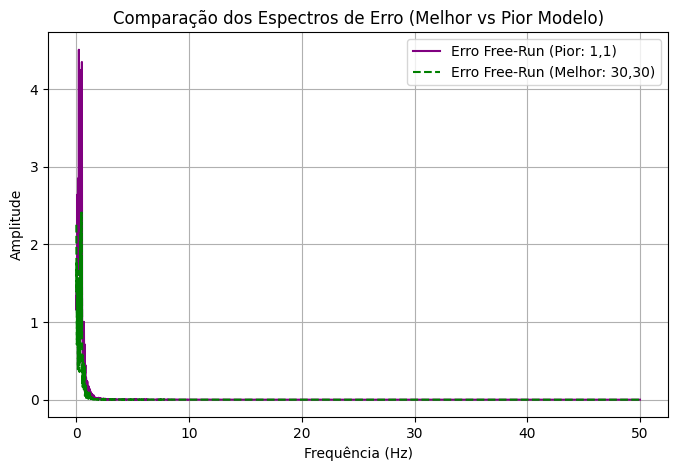

In [183]:
# Comparação do Espectro entre o Melhor e o Pior Modelo (Validação)
worst = df_res.loc[df_res['R2_FR_TST'].idxmin()]
print(f"Pior configuração (R² Free-Run na Validação): na={int(worst.na)}, nb={int(worst.nb)}")
print(f"Melhor configuração (R² Free-Run na Validação): na={int(best.na)}, nb={int(best.nb)}")

na_w, nb_w = int(worst.na), int(worst.nb)
p_w = max(na_w, nb_w)

# Estimar e simular o pior modelo
Phi_tra_w, y_tra_w = create_regression_matrix(u_TRA,  y_TRA,  na_w, nb_w)
Phi_tst_w, y_tst_w = create_regression_matrix(u_TEST, y_TEST, na_w, nb_w)
th_w, _, _, _ = np.linalg.lstsq(Phi_tra_w, y_tra_w, rcond=None)
fr_tst_w = free_run_simulation(th_w, u_TEST, y_TEST, na_w, nb_w)

# Alinhamento das matrizes
p_max = max(p_w, p_b)

y_tst_b_aligned = y_tst_b[p_max - p_b:]
fr_tst_b_aligned = fr_tst_b[p_max - p_b:]
y_tst_w_aligned = y_tst_w[p_max - p_w:]
fr_tst_w_aligned = fr_tst_w[p_max - p_w:]

# Sinais de erro (Validação) para os melhores e piores
erro_FR_best = y_tst_b_aligned.flatten() - fr_tst_b_aligned.flatten()
erro_FR_worst = y_tst_w_aligned.flatten() - fr_tst_w_aligned.flatten()

# Calcular espectros
_, amp_erro_best = espectro_amplitude(erro_FR_best, Ts)
xf, amp_erro_worst = espectro_amplitude(erro_FR_worst, Ts)

fig, axes = plt.subplots(1, 1, figsize=(8, 5))
axes.plot(xf, amp_erro_worst, label=f'Erro Free-Run (Pior: {na_w},{nb_w})', color='purple', lw=1.5)
axes.plot(xf, amp_erro_best, label=f'Erro Free-Run (Melhor: {na_b},{nb_b})', color='green', lw=1.5, ls='--')
axes.set_title('Comparação dos Espectros de Erro (Melhor vs Pior Modelo)')
axes.set_xlabel('Frequência (Hz)')
axes.set_ylabel('Amplitude')
axes.legend()
axes.grid(True)
plt.show()